<a href="https://colab.research.google.com/github/CodeKoala995/northstar-analytics/blob/main/python_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load all CSVs
customers = pd.read_csv("/content/drive/MyDrive/NorthStar/customers.csv")
orders = pd.read_csv("/content/drive/MyDrive/NorthStar/orders.csv")
deliveries = pd.read_csv("/content/drive/MyDrive/NorthStar/deliveries.csv")
complaints = pd.read_csv("/content/drive/MyDrive/NorthStar/complaints.csv")
drivers = pd.read_csv("/content/drive/MyDrive/NorthStar/drivers.csv")
vehicles = pd.read_csv("/content/drive/MyDrive/NorthStar/vehicles.csv")
hubs = pd.read_csv("/content/drive/MyDrive/NorthStar/hubs.csv")
incidents = pd.read_csv("/content/drive/MyDrive/NorthStar/incidents.csv")
app_events = pd.read_csv("/content/drive/MyDrive/NorthStar/app_events.csv")

print("All files loaded!")

All files loaded!


In [3]:
# SECTION 1: DATA EXPLORATION

print("=== DATASET SHAPES ===")
print(f"Orders: {orders.shape}")
print(f"Deliveries: {deliveries.shape}")
print(f"Complaints: {complaints.shape}")
print(f"Customers: {customers.shape}")
print(f"Drivers: {drivers.shape}")
print(f"Vehicles: {vehicles.shape}")
print(f"Hubs: {hubs.shape}")
print(f"Incidents: {incidents.shape}")
print(f"App Events: {app_events.shape}")

=== DATASET SHAPES ===
Orders: (1250, 11)
Deliveries: (950, 13)
Complaints: (320, 10)
Customers: (650, 9)
Drivers: (170, 8)
Vehicles: (120, 8)
Hubs: (8, 5)
Incidents: (280, 7)
App Events: (640, 10)


In [4]:
# SECTION 2: DATA QUALITY CHECK

dataframes = {
    'orders': orders,
    'deliveries': deliveries,
    'complaints': complaints,
    'customers': customers,
    'drivers': drivers,
    'vehicles': vehicles,
    'hubs': hubs,
    'incidents': incidents
}

print("=== MISSING VALUES PER DATASET ===")
for name, df in dataframes.items():
    missing = df.isnull().sum().sum()
    print(f"{name}: {missing} missing values")

=== MISSING VALUES PER DATASET ===
orders: 25 missing values
deliveries: 33 missing values
complaints: 16 missing values
customers: 33 missing values
drivers: 7 missing values
vehicles: 4 missing values
hubs: 0 missing values
incidents: 17 missing values


In [5]:
# SECTION 3: DATA CLEANING

# Standardise zone names to uppercase
orders['pickup_zone'] = orders['pickup_zone'].str.upper().str.strip()
orders['dropoff_zone'] = orders['dropoff_zone'].str.upper().str.strip()
customers['home_zone'] = customers['home_zone'].str.upper().str.strip()
drivers['base_zone'] = drivers['base_zone'].str.upper().str.strip()
hubs['zone'] = hubs['zone'].str.upper().str.strip()

# Fix missing customer ratings - fill with median
deliveries['customer_rating_post_delivery'] = deliveries['customer_rating_post_delivery'].fillna(
    deliveries['customer_rating_post_delivery'].median()
)

# Fix missing compensation - fill with 0 (no compensation given)
complaints['compensation_amount'] = complaints['compensation_amount'].fillna(0)

# Convert date columns to datetime
orders['order_created_at'] = pd.to_datetime(orders['order_created_at'])
deliveries['dispatch_time'] = pd.to_datetime(deliveries['dispatch_time'])
deliveries['delivery_completed_at'] = pd.to_datetime(deliveries['delivery_completed_at'])
complaints['created_at'] = pd.to_datetime(complaints['created_at'])

print("Data cleaning complete!")
print(f"\nZone names in orders: {sorted(orders['pickup_zone'].unique())}")

Data cleaning complete!

Zone names in orders: ['AIRPORT', 'CENTRAL', 'CTR', 'EAST', 'NORTH', 'RIVERSIDE', 'SOUTH', 'WEST']


In [9]:
# SECTION 4: MERGE DATASETS

# Merge orders + deliveries
orders_deliveries = pd.merge(orders, deliveries, on='order_id', how='left')

print("Orders + Deliveries columns:")
print(orders_deliveries.columns.tolist())

# Add complaints - drop duplicate customer_id from complaints first
complaints_clean = complaints.drop(columns=['customer_id'])
orders_deliveries_complaints = pd.merge(
    orders_deliveries, complaints_clean, on='order_id', how='left'
)

# Add customer info
master = pd.merge(
    orders_deliveries_complaints, customers, on='customer_id', how='left'
)

# Add hub info
master = pd.merge(master, hubs, on='hub_id', how='left')

print(f"\nMaster dataset shape: {master.shape}")
print(f"Columns: {master.columns.tolist()}")

Orders + Deliveries columns:
['order_id', 'customer_id', 'service_type', 'order_created_at', 'promised_window_hours', 'pickup_zone', 'dropoff_zone', 'priority_level', 'order_value', 'booking_channel', 'special_handling_flag', 'delivery_id', 'driver_id', 'vehicle_id', 'hub_id', 'dispatch_time', 'delivery_completed_at', 'delivery_status', 'route_distance_km', 'manual_route_override_count', 'proof_of_completion_missing', 'customer_rating_post_delivery', 'fuel_or_charge_cost']

Master dataset shape: (1285, 43)
Columns: ['order_id', 'customer_id', 'service_type', 'order_created_at', 'promised_window_hours', 'pickup_zone', 'dropoff_zone', 'priority_level', 'order_value', 'booking_channel', 'special_handling_flag', 'delivery_id', 'driver_id', 'vehicle_id', 'hub_id', 'dispatch_time', 'delivery_completed_at', 'delivery_status', 'route_distance_km', 'manual_route_override_count', 'proof_of_completion_missing', 'customer_rating_post_delivery', 'fuel_or_charge_cost', 'complaint_id', 'complaint_typ

=== DELIVERY STATUS BREAKDOWN ===
OnTime: 616 (64.84%)
Delayed: 202 (21.26%)
Failed: 132 (13.89%)


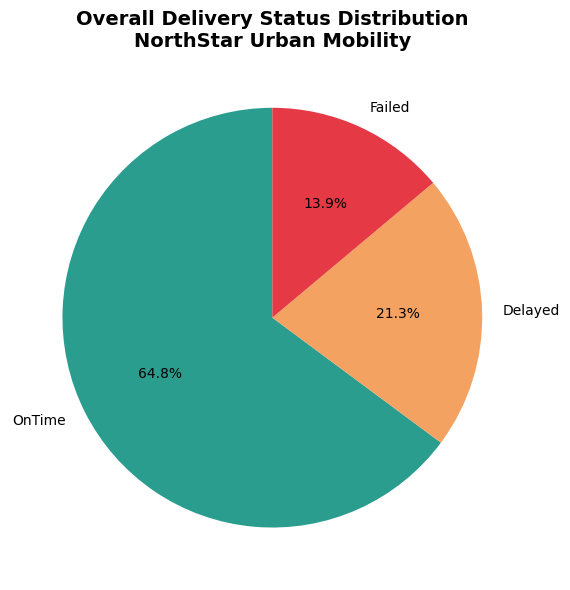

Chart saved!


In [10]:
# ANALYSIS 1: Overall delivery status breakdown

status_counts = deliveries['delivery_status'].value_counts()
percentages = (status_counts / len(deliveries) * 100).round(2)

print("=== DELIVERY STATUS BREAKDOWN ===")
for status, count in status_counts.items():
    print(f"{status}: {count} ({percentages[status]}%)")

# Pie chart
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#2A9D8F', '#F4A261', '#E63946']
ax.pie(status_counts.values,
       labels=status_counts.index,
       autopct='%1.1f%%',
       colors=colors,
       startangle=90)
ax.set_title('Overall Delivery Status Distribution\nNorthStar Urban Mobility',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('delivery_status_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

=== COST ANALYSIS BY ZONE ===
  pickup_zone  avg_cost  total_cost  total_orders  avg_order_value  cost_to_value_ratio
0     AIRPORT     17.08     1981.12           148           103.40                16.52
3        EAST     12.51     2001.19           211            90.97                13.75
6       SOUTH     12.49     1786.44           187            90.25                13.84
5   RIVERSIDE     12.35     1518.94           157            84.97                14.53
1     CENTRAL     12.19     1352.96           161            85.80                14.21
2         CTR     12.11      786.87            81            93.93                12.89
4       NORTH     12.03     1660.46           177            91.05                13.21
7        WEST     12.00     1403.69           163            91.09                13.17


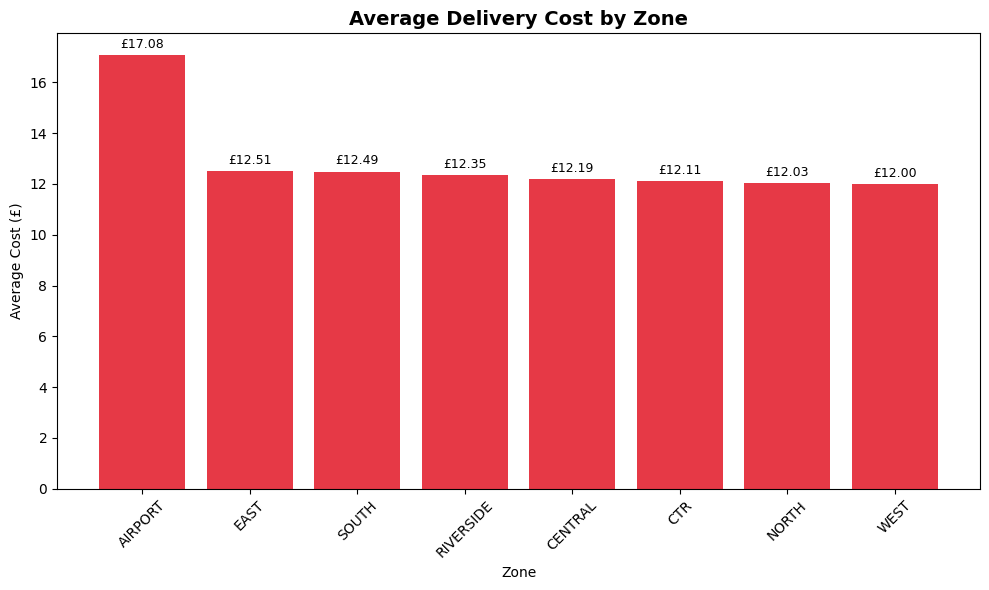

In [11]:
# ANALYSIS 2: Operational cost analysis by zone

cost_by_zone = master.groupby('pickup_zone').agg(
    avg_cost=('fuel_or_charge_cost', 'mean'),
    total_cost=('fuel_or_charge_cost', 'sum'),
    total_orders=('order_id', 'count'),
    avg_order_value=('order_value', 'mean')
).round(2).reset_index()

cost_by_zone['cost_to_value_ratio'] = (
    cost_by_zone['avg_cost'] / cost_by_zone['avg_order_value'] * 100
).round(2)

print("=== COST ANALYSIS BY ZONE ===")
print(cost_by_zone.sort_values('avg_cost', ascending=False).to_string())

# Bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    cost_by_zone.sort_values('avg_cost', ascending=False)['pickup_zone'],
    cost_by_zone.sort_values('avg_cost', ascending=False)['avg_cost'],
    color='#E63946'
)
ax.bar_label(bars, fmt='£%.2f', padding=3, fontsize=9)
ax.set_title('Average Delivery Cost by Zone', fontsize=14, fontweight='bold')
ax.set_xlabel('Zone')
ax.set_ylabel('Average Cost (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('cost_by_zone.png', dpi=150, bbox_inches='tight')
plt.show()

=== ZONE PERFORMANCE RATES ===
  pickup_zone  total  failed  delayed  on_time  failure_rate  delay_rate  success_rate
1     CENTRAL    111      22       27       62         19.82       24.32         55.86
2         CTR     65      11       24       30         16.92       36.92         46.15
4       NORTH    138      22       22       94         15.94       15.94         68.12
5   RIVERSIDE    123      19       26       78         15.45       21.14         63.41
3        EAST    160      20       31      109         12.50       19.38         68.12
7        WEST    117      14       22       81         11.97       18.80         69.23
0     AIRPORT    116      12       31       73         10.34       26.72         62.93
6       SOUTH    143      14       22      107          9.79       15.38         74.83


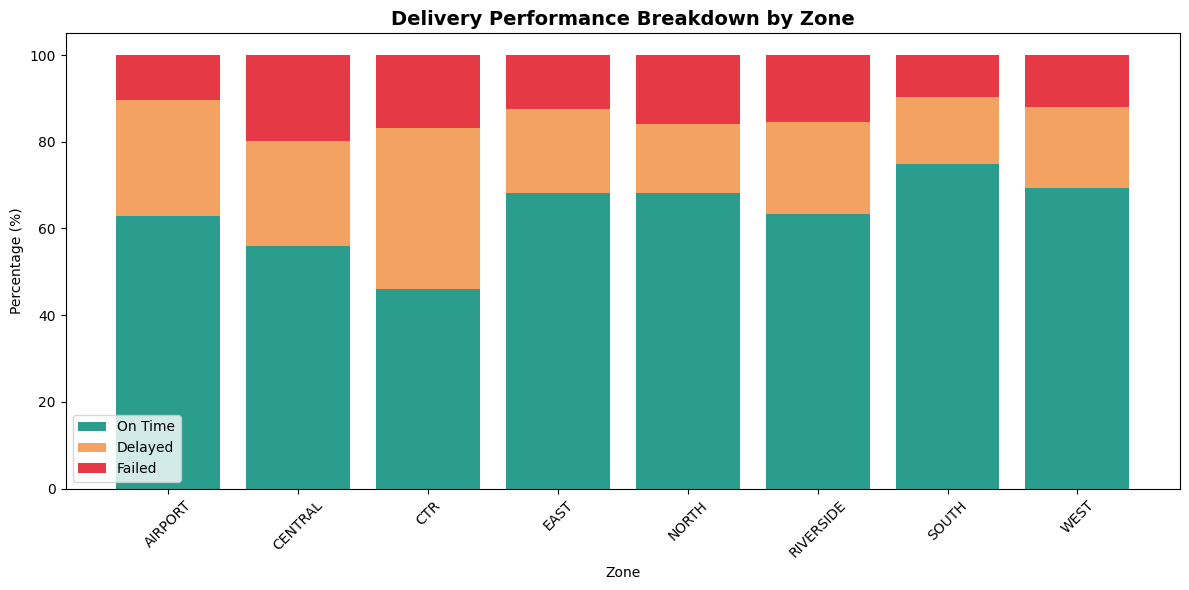

In [12]:
# ANALYSIS 3: Failure rate by zone using NumPy

zone_performance = master.groupby('pickup_zone').agg(
    total=('delivery_status', 'count'),
    failed=('delivery_status', lambda x: (x == 'Failed').sum()),
    delayed=('delivery_status', lambda x: (x == 'Delayed').sum()),
    on_time=('delivery_status', lambda x: (x == 'OnTime').sum())
).reset_index()

# NumPy calculations
zone_performance['failure_rate'] = np.round(
    zone_performance['failed'] / zone_performance['total'] * 100, 2
)
zone_performance['delay_rate'] = np.round(
    zone_performance['delayed'] / zone_performance['total'] * 100, 2
)
zone_performance['success_rate'] = np.round(
    zone_performance['on_time'] / zone_performance['total'] * 100, 2
)

print("=== ZONE PERFORMANCE RATES ===")
print(zone_performance.sort_values('failure_rate', ascending=False).to_string())

# Stacked bar chart
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(zone_performance))
ax.bar(x, zone_performance['success_rate'], label='On Time', color='#2A9D8F')
ax.bar(x, zone_performance['delay_rate'],
       bottom=zone_performance['success_rate'], label='Delayed', color='#F4A261')
ax.bar(x, zone_performance['failure_rate'],
       bottom=zone_performance['success_rate'] + zone_performance['delay_rate'],
       label='Failed', color='#E63946')
ax.set_xticks(x)
ax.set_xticklabels(zone_performance['pickup_zone'], rotation=45)
ax.set_title('Delivery Performance Breakdown by Zone', fontsize=14, fontweight='bold')
ax.set_xlabel('Zone')
ax.set_ylabel('Percentage (%)')
ax.legend()
plt.tight_layout()
plt.savefig('zone_performance.png', dpi=150, bbox_inches='tight')
plt.show()

=== CORRELATION MATRIX ===
                               order_value  fuel_or_charge_cost  \
order_value                           1.00                 0.03   
fuel_or_charge_cost                   0.03                 1.00   
manual_route_override_count          -0.01                 0.06   
customer_rating_post_delivery        -0.14                 0.01   
resolution_days                       0.09                -0.01   
compensation_amount                  -0.10                -0.10   
loyalty_score                         0.00                 0.13   
app_engagement_score                  0.06                 0.19   

                               manual_route_override_count  \
order_value                                          -0.01   
fuel_or_charge_cost                                   0.06   
manual_route_override_count                           1.00   
customer_rating_post_delivery                        -0.12   
resolution_days                                      -0.01 

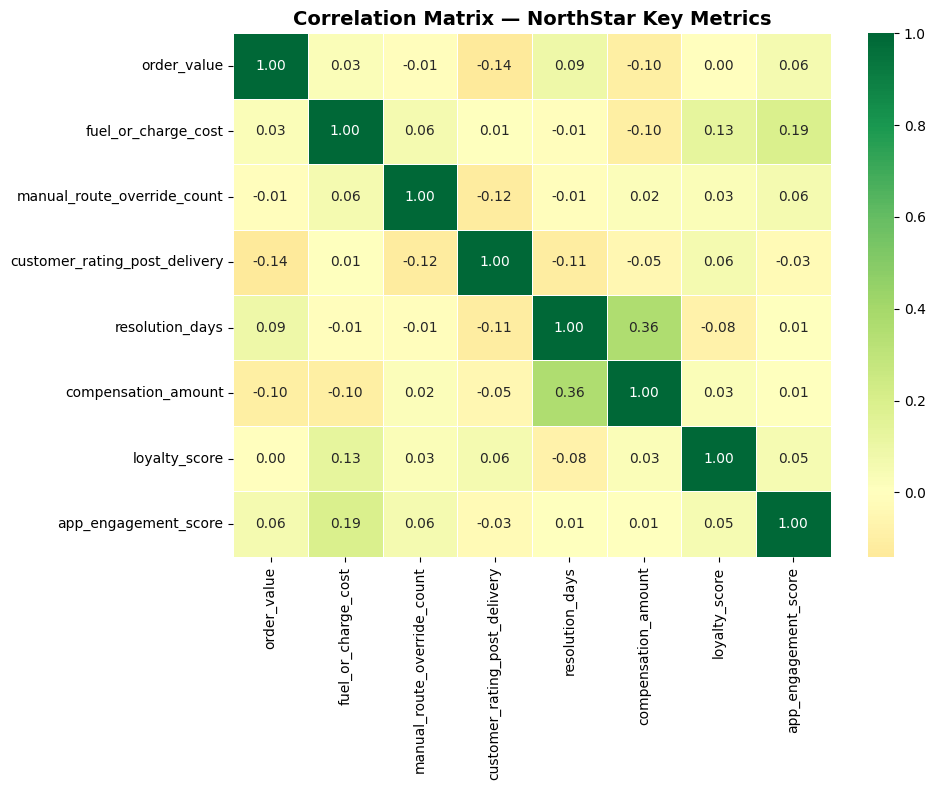

In [13]:
# ANALYSIS 4: Correlation analysis using NumPy

# Select numeric columns for correlation
numeric_cols = master[[
    'order_value',
    'fuel_or_charge_cost',
    'manual_route_override_count',
    'customer_rating_post_delivery',
    'resolution_days',
    'compensation_amount',
    'loyalty_score',
    'app_engagement_score'
]].dropna()

correlation_matrix = numeric_cols.corr().round(2)

print("=== CORRELATION MATRIX ===")
print(correlation_matrix)

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    ax=ax,
    linewidths=0.5
)
ax.set_title('Correlation Matrix — NorthStar Key Metrics',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

=== COMPLAINT TYPE BREAKDOWN ===
      complaint_type  count
0              Delay    101
1       MissedPickup     64
2           AppIssue     53
3    DriverBehaviour     51
4  SupportExperience     20
5            Billing     16
6             Damage     15


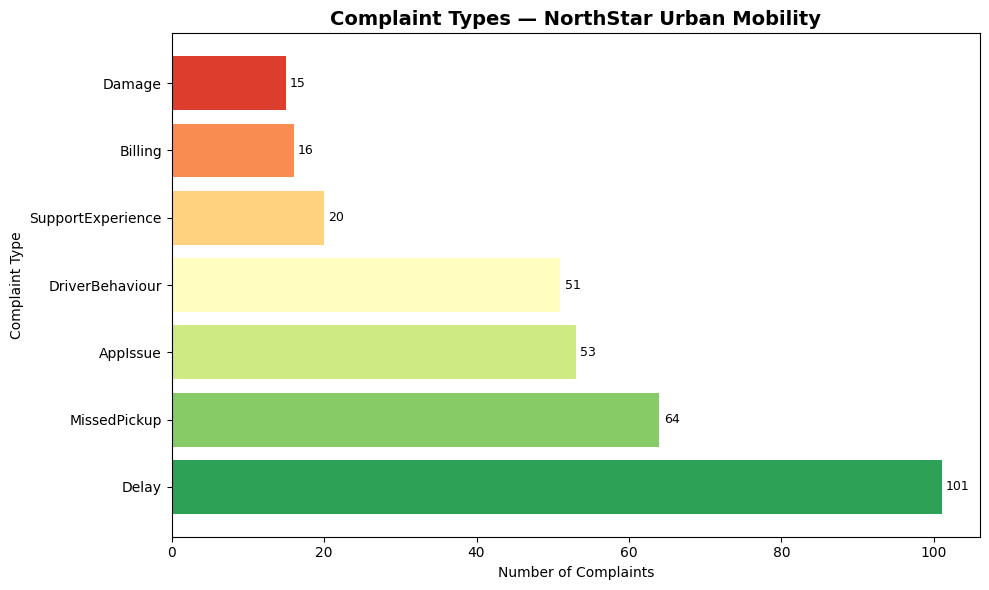

In [14]:
# ANALYSIS 5: Complaint type breakdown

complaint_counts = complaints['complaint_type'].value_counts().reset_index()
complaint_counts.columns = ['complaint_type', 'count']

print("=== COMPLAINT TYPE BREAKDOWN ===")
print(complaint_counts.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    complaint_counts['complaint_type'],
    complaint_counts['count'],
    color=sns.color_palette('RdYlGn_r', len(complaint_counts))
)
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title('Complaint Types — NorthStar Urban Mobility',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Complaints')
ax.set_ylabel('Complaint Type')
plt.tight_layout()
plt.savefig('complaint_types.png', dpi=150, bbox_inches='tight')
plt.show()

=== CUSTOMER TYPE PERFORMANCE ===
  customer_type  total_orders  avg_order_value  failed_deliveries  avg_rating  avg_compensation  avg_loyalty  failure_rate
0      Consumer           947            90.07                 98        3.88             19.69        60.84         10.35
1    Enterprise           122            99.37                  8        3.87             18.78        58.80          6.56
2           SME           216            91.13                 28        3.83             17.36        55.95         12.96


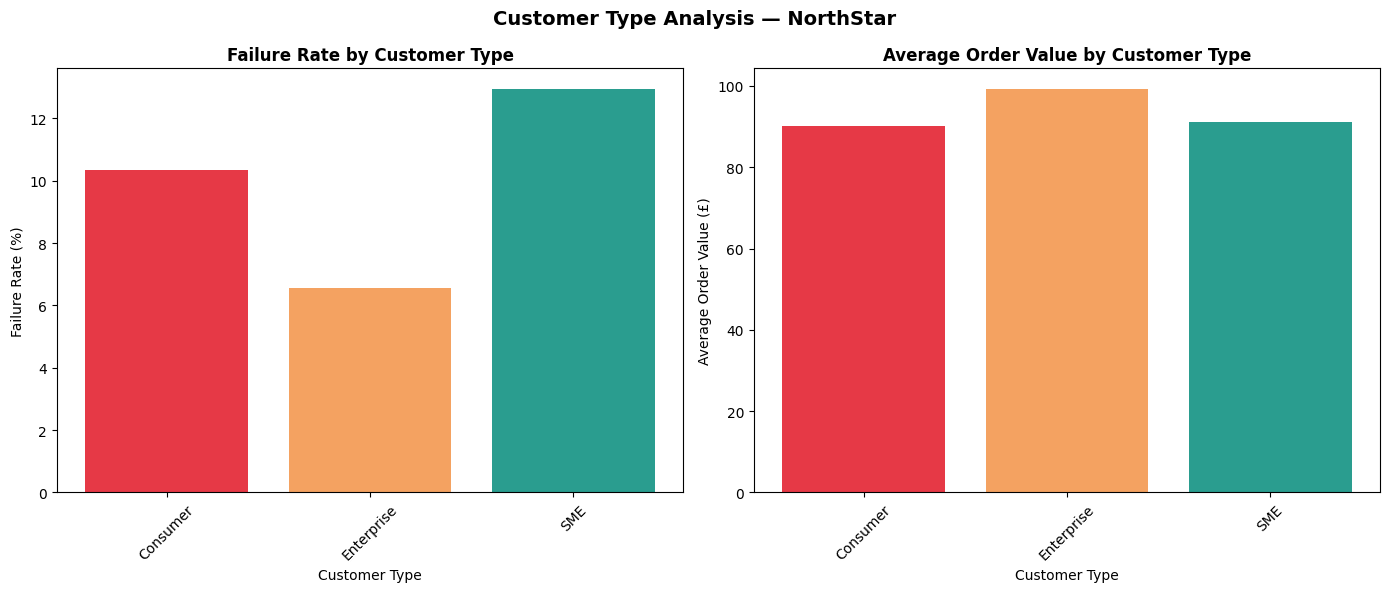

In [15]:
# ANALYSIS 6: Customer type vs service performance

customer_performance = master.groupby('customer_type').agg(
    total_orders=('order_id', 'count'),
    avg_order_value=('order_value', 'mean'),
    failed_deliveries=('delivery_status', lambda x: (x == 'Failed').sum()),
    avg_rating=('customer_rating_post_delivery', 'mean'),
    avg_compensation=('compensation_amount', 'mean'),
    avg_loyalty=('loyalty_score', 'mean')
).round(2).reset_index()

customer_performance['failure_rate'] = np.round(
    customer_performance['failed_deliveries'] /
    customer_performance['total_orders'] * 100, 2
)

print("=== CUSTOMER TYPE PERFORMANCE ===")
print(customer_performance.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1 - failure rate
axes[0].bar(
    customer_performance['customer_type'],
    customer_performance['failure_rate'],
    color=['#E63946', '#F4A261', '#2A9D8F', '#457B9D']
)
axes[0].set_title('Failure Rate by Customer Type', fontweight='bold')
axes[0].set_xlabel('Customer Type')
axes[0].set_ylabel('Failure Rate (%)')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2 - avg order value
axes[1].bar(
    customer_performance['customer_type'],
    customer_performance['avg_order_value'],
    color=['#E63946', '#F4A261', '#2A9D8F', '#457B9D']
)
axes[1].set_title('Average Order Value by Customer Type', fontweight='bold')
axes[1].set_xlabel('Customer Type')
axes[1].set_ylabel('Average Order Value (£)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Customer Type Analysis — NorthStar',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('customer_type_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

=== EVENT TYPE BREAKDOWN ===
                    event_type  count
0                  track_order    138
1                  eta_refresh    105
2                 search_route     99
3                  chat_opened     88
4  delivery_instruction_update     75
5                payment_retry     69
6               chat_escalated     38
7               cancel_attempt     28

=== APP PERFORMANCE STATS ===
Total app events: 640
Average API latency: 465.67ms
Success rate: 94.06%
Failed events: 38


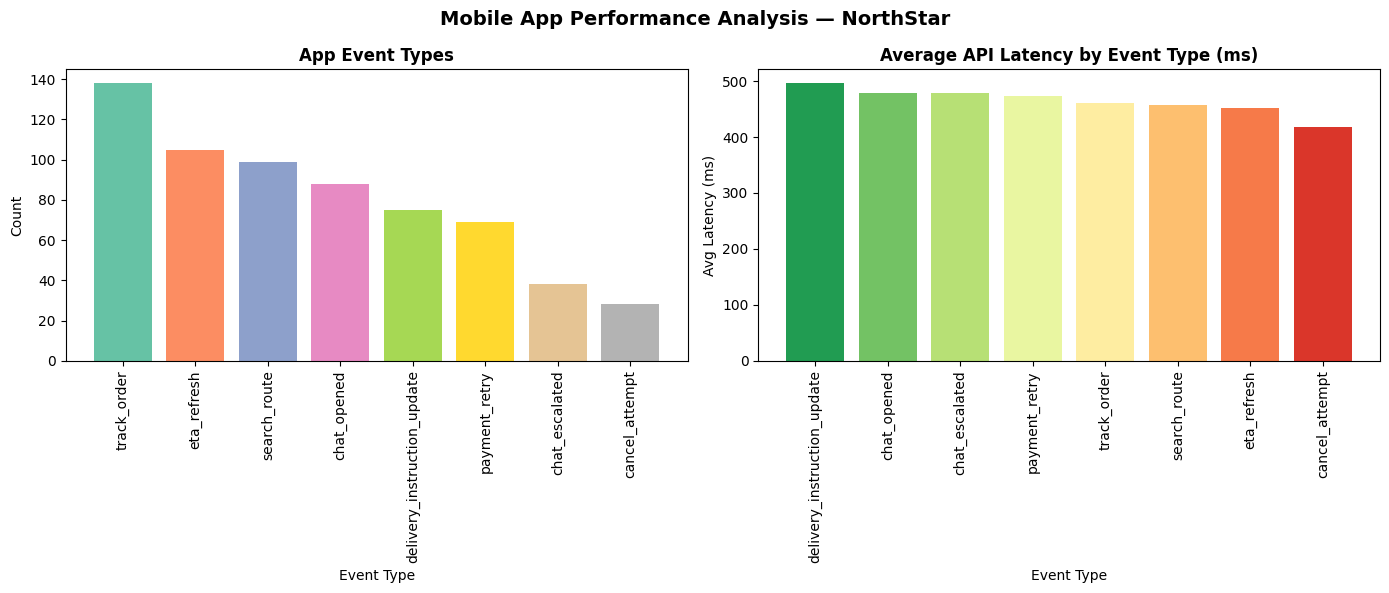

In [20]:
# ANALYSIS 7: App Events Analysis

# Fix zone context to uppercase
app_events['zone_context'] = app_events['zone_context'].str.upper().str.strip()

# Event type breakdown
event_counts = app_events['event_type'].value_counts().reset_index()
event_counts.columns = ['event_type', 'count']

print("=== EVENT TYPE BREAKDOWN ===")
print(event_counts)

print(f"\n=== APP PERFORMANCE STATS ===")
print(f"Total app events: {len(app_events)}")
print(f"Average API latency: {app_events['api_latency_ms'].mean():.2f}ms")
print(f"Success rate: {app_events['success_flag'].mean()*100:.2f}%")
print(f"Failed events: {(app_events['success_flag']==0).sum()}")

# Chart 1 - Event types
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(event_counts['event_type'],
            event_counts['count'],
            color=sns.color_palette('Set2', len(event_counts)))
axes[0].set_title('App Event Types', fontweight='bold')
axes[0].set_xlabel('Event Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=90)

# Chart 2 - API latency by event type
latency_by_event = app_events.groupby('event_type')['api_latency_ms'].mean().reset_index()
latency_by_event.columns = ['event_type', 'avg_latency']
latency_by_event = latency_by_event.sort_values('avg_latency', ascending=False)

axes[1].bar(latency_by_event['event_type'],
            latency_by_event['avg_latency'],
            color=sns.color_palette('RdYlGn_r', len(latency_by_event)))
axes[1].set_title('Average API Latency by Event Type (ms)', fontweight='bold')
axes[1].set_xlabel('Event Type')
axes[1].set_ylabel('Avg Latency (ms)')
axes[1].tick_params(axis='x', rotation=90)

plt.suptitle('Mobile App Performance Analysis — NorthStar',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('app_events_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

=== KEY PERFORMANCE INDICATORS ===

Overall failure rate: 13.89%
Overall delay rate: 21.26%
Combined non-performance rate: 35.15%

Average delivery cost: £12.84
Std deviation of cost: £4.34
Maximum delivery cost: £29.43

Total complaints: 320
Complaints per delivery: 0.337
Average resolution time: 7.93 days
Average compensation paid: £19.24
Currently open complaints: 56

Average route overrides per delivery: 0.97
Deliveries with more than 2 overrides: 88


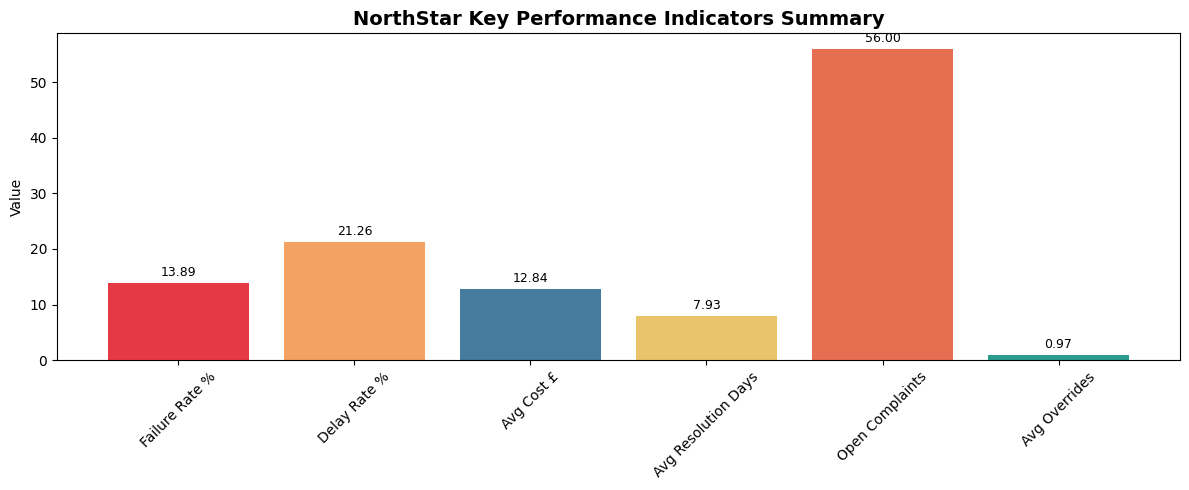


Python analysis complete!


In [18]:
# ANALYSIS 8: NumPy Summary Statistics

print("=== KEY PERFORMANCE INDICATORS ===\n")

# Delivery KPIs
total_deliveries = len(deliveries)
failure_rate = np.round((deliveries['delivery_status'] == 'Failed').sum() / total_deliveries * 100, 2)
delay_rate = np.round((deliveries['delivery_status'] == 'Delayed').sum() / total_deliveries * 100, 2)

print(f"Overall failure rate: {failure_rate}%")
print(f"Overall delay rate: {delay_rate}%")
print(f"Combined non-performance rate: {np.round(failure_rate + delay_rate, 2)}%")

# Cost KPIs
avg_cost = np.round(deliveries['fuel_or_charge_cost'].mean(), 2)
std_cost = np.round(deliveries['fuel_or_charge_cost'].std(), 2)
max_cost = np.round(deliveries['fuel_or_charge_cost'].max(), 2)

print(f"\nAverage delivery cost: £{avg_cost}")
print(f"Std deviation of cost: £{std_cost}")
print(f"Maximum delivery cost: £{max_cost}")

# Complaint KPIs
total_complaints = len(complaints)
avg_resolution = np.round(complaints['resolution_days'].mean(), 2)
avg_compensation = np.round(complaints['compensation_amount'].mean(), 2)
open_complaints = (complaints['status'] == 'Open').sum()

print(f"\nTotal complaints: {total_complaints}")
print(f"Complaints per delivery: {np.round(total_complaints/total_deliveries, 3)}")
print(f"Average resolution time: {avg_resolution} days")
print(f"Average compensation paid: £{avg_compensation}")
print(f"Currently open complaints: {open_complaints}")

# Route override KPIs
avg_overrides = np.round(deliveries['manual_route_override_count'].mean(), 2)
high_override = (deliveries['manual_route_override_count'] > 2).sum()

print(f"\nAverage route overrides per delivery: {avg_overrides}")
print(f"Deliveries with more than 2 overrides: {high_override}")

# Visualise KPIs
kpis = {
    'Failure Rate %': failure_rate,
    'Delay Rate %': delay_rate,
    'Avg Cost £': avg_cost,
    'Avg Resolution Days': avg_resolution,
    'Open Complaints': open_complaints,
    'Avg Overrides': avg_overrides
}

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(kpis.keys(), kpis.values(),
              color=['#E63946', '#F4A261', '#457B9D', '#E9C46A', '#E76F51', '#2A9D8F'])
ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
ax.set_title('NorthStar Key Performance Indicators Summary',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('kpi_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPython analysis complete!")